<a href="https://colab.research.google.com/github/ngzhiwei517/Fetal-Distress-Detection/blob/main/Fetal_distress_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1️ Data Exploration & Understanding

In [54]:
import pandas as pd
df=pd.read_csv('/content/CTG.csv')
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,1/12/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,3/5/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,3/5/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,3/5/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,3/5/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [55]:
df.iloc[0] #index 0

,0
FileName,Variab10.txt
Date,1/12/1996
SegFile,CTG0001.txt
b,240.0
e,357.0
LBE,120.0
LB,120.0
AC,0.0
FM,0.0
UC,0.0


In [56]:
df = df.iloc[1:].reset_index(drop=True)
df

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Fmcs_1.txt,3/5/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
1,Fmcs_1.txt,3/5/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,3/5/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,3/5/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
4,Fmcs_2.txt,3/5/1996,CTG0006.txt,0.0,953.0,134.0,134.0,1.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2123,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2124,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
df.shape

(2128, 40)

In [58]:
df.columns

Index(['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC',
       'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min',
       'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance',
       'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP',
       'CLASS', 'NSP'],
      dtype='object')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2125 non-null   object 
 1   Date      2125 non-null   object 
 2   SegFile   2125 non-null   object 
 3   b         2125 non-null   float64
 4   e         2125 non-null   float64
 5   LBE       2125 non-null   float64
 6   LB        2125 non-null   float64
 7   AC        2125 non-null   float64
 8   FM        2126 non-null   float64
 9   UC        2126 non-null   float64
 10  ASTV      2126 non-null   float64
 11  MSTV      2126 non-null   float64
 12  ALTV      2126 non-null   float64
 13  MLTV      2126 non-null   float64
 14  DL        2127 non-null   float64
 15  DS        2127 non-null   float64
 16  DP        2127 non-null   float64
 17  DR        2127 non-null   float64
 18  Width     2125 non-null   float64
 19  Min       2125 non-null   float64
 20  Max       2125 non-null   floa

Many columns that should be numeric are currently of type object:

Examples:

LB (baseline heart rate)

AC, FM, UC

In [60]:
df.isna().sum()

,0
FileName,3
Date,3
SegFile,3
b,3
e,3
LBE,3
LB,3
AC,3
FM,2
UC,2


In [61]:
df['NSP'].value_counts().sort_index()

,count
NSP,
1.0,1655
2.0,294
3.0,176


Key observations

Highly imbalanced dataset

Normal ≈ 78%

Suspect ≈ 14%

Pathologic ≈ 8%

The dataset exhibits strong class imbalance, with Normal cases dominating. Therefore, stratified splitting was used during train–test split and cross-validation to ensure consistent class representation across folds.



---


Doctors’ CTG flow:

Baseline

Variability

Accelerations

Decelerations

Overall pattern

# ① Baseline (LB)

## LB — Histogram

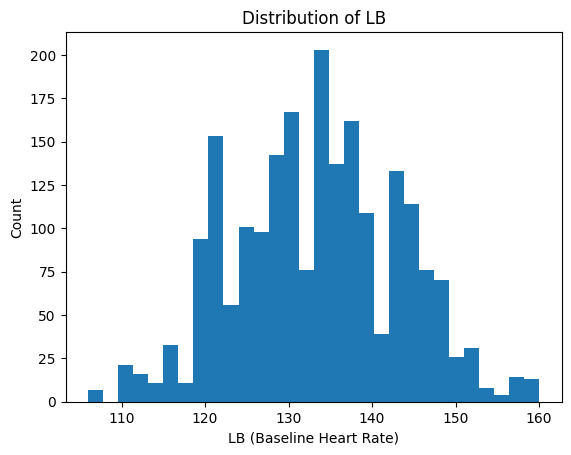

In [62]:
import matplotlib.pyplot as plt

lb = pd.to_numeric(df['LB'], errors='coerce')

plt.figure()
plt.hist(lb.dropna(), bins=30)
plt.xlabel('LB (Baseline Heart Rate)')
plt.ylabel('Count')
plt.title('Distribution of LB')
plt.show()


Observation from the histogram

* Most LB values cluster between 120–145 bpm

* The distribution is roughly bell-shaped, centered around ~130–140 bpm

EDA interpretation
* The majority of samples lie within the clinically normal range (110–160 bpm)

## LB vs NSP — Boxplot

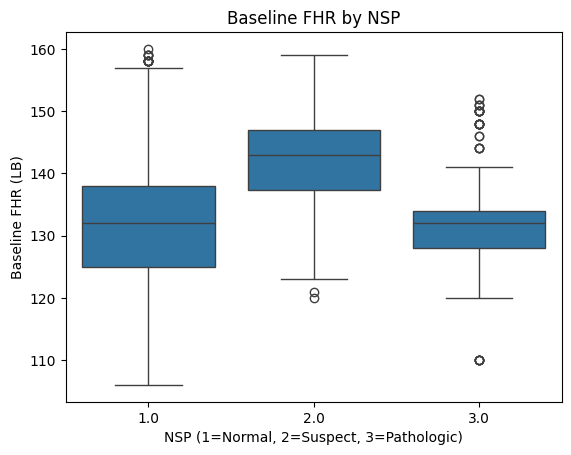

In [63]:
import seaborn as sns

plt.figure()
sns.boxplot(x='NSP', y=lb, data=df.assign(LB_num=lb))
plt.xlabel('NSP (1=Normal, 2=Suspect, 3=Pathologic)')
plt.ylabel('Baseline FHR (LB)')
plt.title('Baseline FHR by NSP')
plt.show()


# ② Variability (ASTV / ALTV)

## ASTV vs NSP

Text(0.5, 1.0, 'Abnormal Short-Term Variability by NSP')

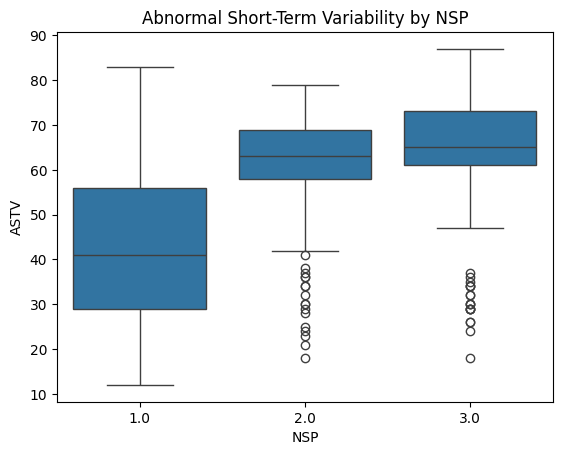

In [64]:
astv = pd.to_numeric(df['ASTV'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=astv, data=df.assign(ASTV_num=astv))
plt.xlabel('NSP')
plt.ylabel('ASTV')
plt.title('Abnormal Short-Term Variability by NSP')


## ALTV vs NSP

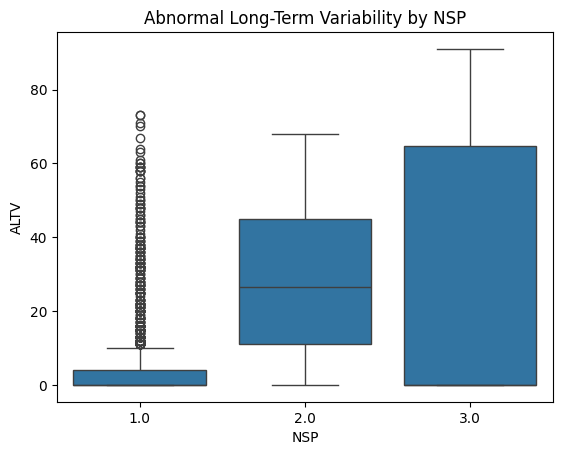

In [65]:
altv = pd.to_numeric(df['ALTV'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=altv, data=df.assign(ALTV_num=altv))
plt.xlabel('NSP')
plt.ylabel('ALTV')
plt.title('Abnormal Long-Term Variability by NSP')
plt.show()


What we see

NSP = 1 (Normal)

* Median ≈ 0

* Very tight IQR near 0

* Many outliers, but core distribution is low

NSP = 2 (Suspect)

* Median shifts upward (~25)

* Wider IQR

NSP = 3 (Pathologic)
* Median much higher
* Very large spread


---


Clinical interpretation

* Normal babies show stable long-term rhythm
* Pathologic cases show highly abnormal long-term variability
* This matches medical intuition perfectly


---


EDA takeaway (important)

* ALTV strongly separates Normal, Suspect, and Pathologic cases.

##



---

EDA shows that abnormal variability features are the strongest indicators of fetal distress. ALTV increases consistently from Normal to Pathologic cases, while ASTV exhibits a non-linear pattern: reduced variability in Suspect cases and erratic variability in Pathologic cases. These findings align with clinical CTG interpretation and suggest that non-linear models are better suited for this task.

### “EDA revealed non-linear, class-dependent variability patterns, so tree-based models were chosen.”

# ③ Accelerations (AC)

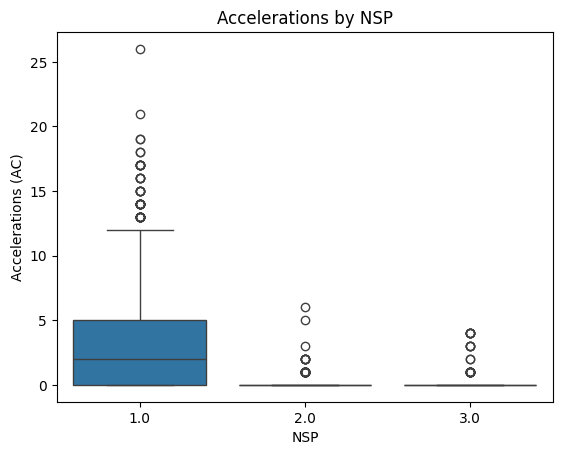

In [66]:
ac = pd.to_numeric(df['AC'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=ac, data=df.assign(AC_num=ac))
plt.xlabel('NSP')
plt.ylabel('Accelerations (AC)')
plt.title('Accelerations by NSP')
plt.show()


Normal cases show higher and more frequent accelerations, with a wider spread of AC values. In contrast, Suspect and Pathologic cases have AC values concentrated near zero, indicating fewer or absent accelerations

* This clear separation suggests that accelerations are a strong discriminative feature between Normal and non-Normal fetal states.

# ④ Decelerations (DS, DP)

## DS vs NSP

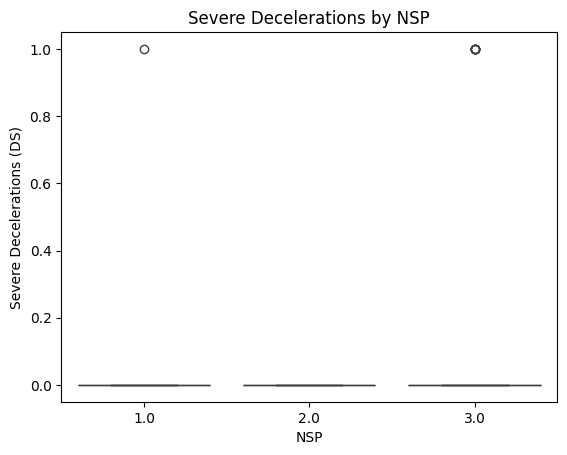

In [67]:
ds = pd.to_numeric(df['DS'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=ds, data=df.assign(DS_num=ds))
plt.xlabel('NSP')
plt.ylabel('Severe Decelerations (DS)')
plt.title('Severe Decelerations by NSP')
plt.show()


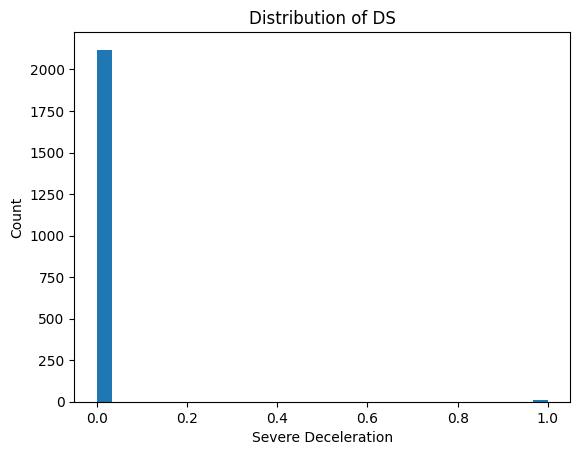

In [68]:
import matplotlib.pyplot as plt

ds = pd.to_numeric(df['DS'], errors='coerce')

plt.figure()
plt.hist(ds.dropna(), bins=30)
plt.xlabel('Severe Deceleration')
plt.ylabel('Count')
plt.title('Distribution of DS')
plt.show()


## DP vs NSP

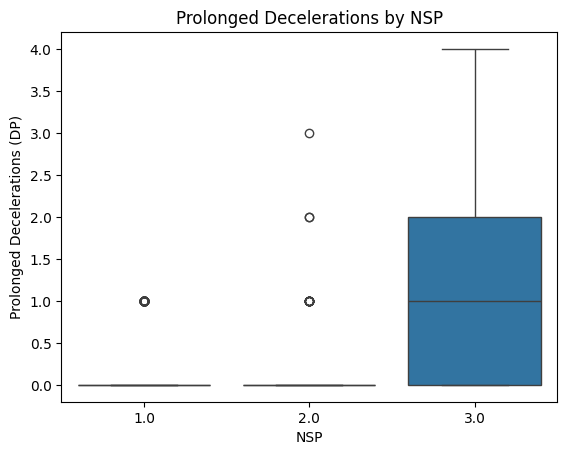

In [69]:
dp = pd.to_numeric(df['DP'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=dp, data=df.assign(DP_num=dp))
plt.xlabel('NSP')
plt.ylabel('Prolonged Decelerations (DP)')
plt.title('Prolonged Decelerations by NSP')
plt.show()


**Prolonged Decelerations (DP)**

Normal cases show almost no prolonged decelerations, with values concentrated at zero. Suspect cases show occasional occurrences, while Pathologic cases have higher DP values and a wider spread.

This pattern indicates that prolonged decelerations are strongly associated with pathological fetal states

# ⑤ Summary — Correlation with Target

### Correlation Heatmap (NSP only)

In [70]:
# Columns that are identifiers (NOT medical signals)
id_cols = ['FileName', 'Date', 'SegFile']

# Columns that are medical measurements but loaded as object
to_numeric_cols = [
    'b','e','LBE','LB','AC','FM','UC','DL','DS','DP',
    'Width','Nmax'
]

df[to_numeric_cols] = df[to_numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)



In [71]:
exclude_cols = ['FileName', 'Date', 'SegFile', 'CLASS']
features = df.drop(columns=exclude_cols)
corr_nsp = (
    features
    .select_dtypes(include='number')
    .corrwith(df['NSP'], method='spearman')
    .sort_values()
)


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


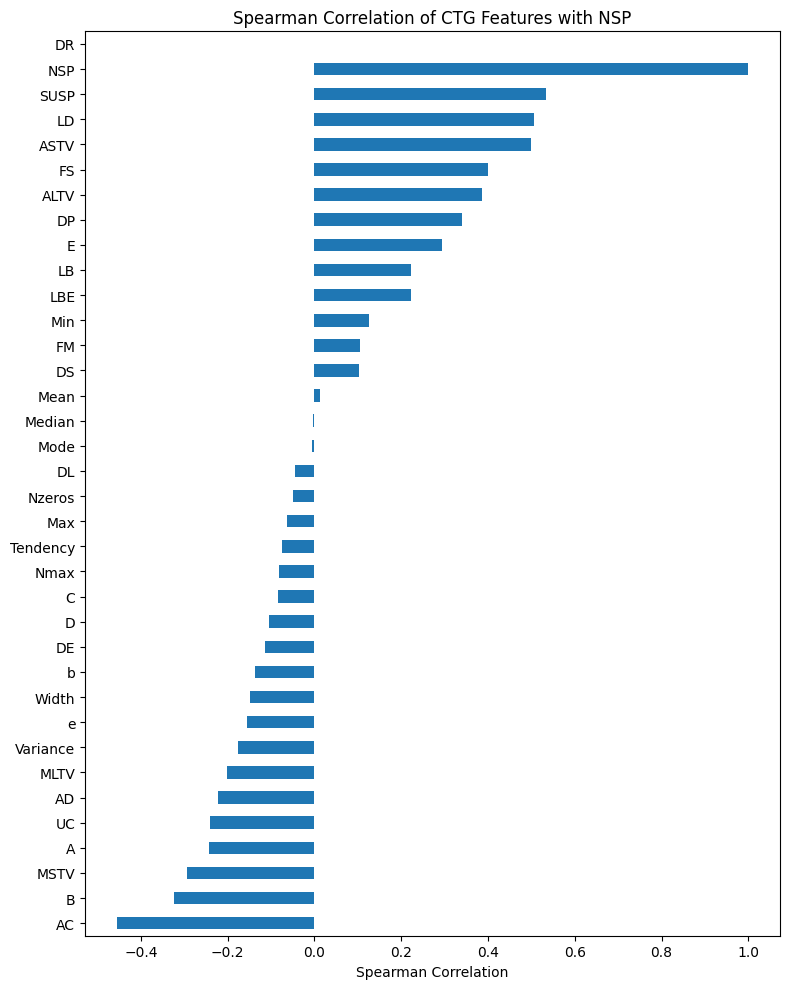

In [72]:
plt.figure(figsize=(8, 10))
corr_nsp.plot(kind='barh')
plt.title('Spearman Correlation of CTG Features with NSP')
plt.xlabel('Spearman Correlation')
plt.tight_layout()
plt.show()


* Baseline heart rate (LB) shows only a moderate correlation, indicating that average heart rate alone is insufficient to determine fetal condition

* Variability-related features (e.g. ASTV, ALTV, ) show stronger correlations with fetal outcome compared to baseline heart rate alone.



* Accelerations (AC) show a negative correlation with NSP, suggesting that more accelerations are associated with healthier (Normal) outcomes.

* Deceleration-related features (DP, DS, DL) are positively associated with worse fetal outcomes, supporting their role as clinical risk indicators.



> No single feature dominates the outcome; instead, fetal status appears to be influenced by a combination of variability, accelerations, and deceleration patterns, which aligns with clinical CTG interpretation.


In [73]:
key_features = [
    'LB','AC','FM','UC','DL','DS','DP',
    'ASTV','ALTV','Variance','Width','CLASS'
]

corr_key = df[key_features].corr()


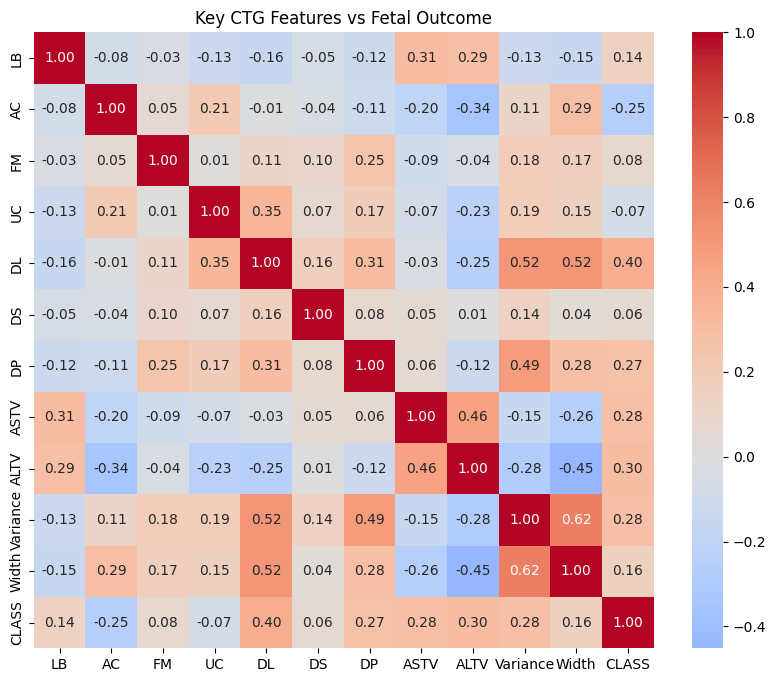

In [74]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_key,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)
plt.title('Key CTG Features vs Fetal Outcome')
plt.show()


# Step 2️ Data Cleaning & Preprocessing



*   Handle null value
*   Scaling and normalising
*   One hot encoding/mapping



### Check & handle missing values

In [75]:
df.isnull().sum()

,0
FileName,3
Date,3
SegFile,3
b,3
e,3
LBE,3
LB,3
AC,3
FM,2
UC,2


In [76]:
df=df.dropna()
df.isna().sum()

,0
FileName,0
Date,0
SegFile,0
b,0
e,0
LBE,0
LB,0
AC,0
FM,0
UC,0


### Separate features and target

In [77]:
cols_to_drop = [
    "Date", "SegFile", "FileName",'NMAX','Nzeros','Tendency','LBE',
    "b", "e", "A", "B", "C", "D", "E",'AD','DE','LD','FS','CLASS','SUSP','NSP'
]

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df["NSP"]

In [78]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2125 entries, 0 to 2124
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2125 non-null   float64
 1   AC        2125 non-null   float64
 2   FM        2125 non-null   float64
 3   UC        2125 non-null   float64
 4   ASTV      2125 non-null   float64
 5   MSTV      2125 non-null   float64
 6   ALTV      2125 non-null   float64
 7   MLTV      2125 non-null   float64
 8   DL        2125 non-null   float64
 9   DS        2125 non-null   float64
 10  DP        2125 non-null   float64
 11  DR        2125 non-null   float64
 12  Width     2125 non-null   float64
 13  Min       2125 non-null   float64
 14  Max       2125 non-null   float64
 15  Nmax      2125 non-null   float64
 16  Mode      2125 non-null   float64
 17  Mean      2125 non-null   float64
 18  Median    2125 non-null   float64
 19  Variance  2125 non-null   float64
dtypes: float64(20)
memory usage: 348.6 

### Stratified train–test split

Due to the imbalanced class distribution, stratified splitting was used to maintain similar class proportions in both training and testing sets, ensuring fair and reliable evaluation.

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Encode target labels (safety check)

In [80]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

### Feature scaling

Why StandardScaler

* Works well with normally distributed features

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [82]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)


(1700, 20)
(425, 20)


Data preprocessing involved removing non-observational rows, handling missing values via deletion, performing stratified train–test splitting, and applying feature scaling while preventing data leakage.

# Step 3️ Baseline Models

### Baseline Model 1 — Logistic Regression

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Normal", "Suspect", "Pathologic"]
))

bal_acc = balanced_accuracy_score(y_test, y_pred_lr)

print("Balanced Accuracy:", bal_acc)

              precision    recall  f1-score   support

      Normal       0.93      0.95      0.94       331
     Suspect       0.60      0.61      0.61        59
  Pathologic       0.79      0.66      0.72        35

    accuracy                           0.88       425
   macro avg       0.78      0.74      0.76       425
weighted avg       0.88      0.88      0.88       425

Balanced Accuracy: 0.7386509440173222


Overall accuracy stands at 88%, but this is heavily influenced by the Normal class which dominates the dataset (331 out of 425 test samples).

Balanced accuracy of 0.74 tells a more honest story — the model performs well on Normal (recall 0.95) but struggles significantly with the minority classes, particularly Pathologic (recall 0.66) and Suspect (recall 0.61).

This highlights the class imbalance challenge and justifies the need for further tuning with a clinically-motivated optimisation strategy.

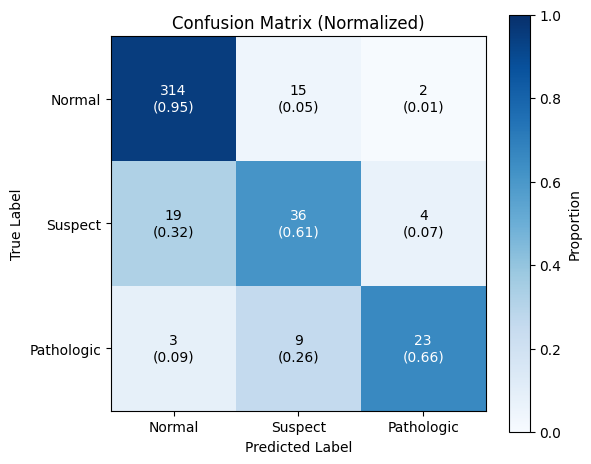

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["Normal", "Suspect", "Pathologic"]

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# optional: normalize by true labels
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()



### Baseline Model 2 — Random Forest

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42

)

rf.fit(X_train_scaled, y_train)  # scaled data is OK

y_pred_rf = rf.predict(X_test_scaled)

In [86]:
from sklearn.metrics import classification_report, balanced_accuracy_score

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Normal", "Suspect", "Pathologic"]
))

bal_acc = balanced_accuracy_score(y_test, y_pred_rf)
print("Balanced Accuracy:", bal_acc)

              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       331
     Suspect       0.83      0.68      0.75        59
  Pathologic       0.94      0.83      0.88        35

    accuracy                           0.93       425
   macro avg       0.90      0.83      0.86       425
weighted avg       0.93      0.93      0.93       425

Balanced Accuracy: 0.8304772633616917


* Overall accuracy of 93%, but inflated by the dominant Normal class (331/425 samples)
* Balanced accuracy of 0.83 is more representative of true model performance
* Normal class: strong recall of 0.98 — model identifies almost all normal cases correctly
* Pathologic class: recall of 0.83 — reasonable given the small support of 35 samples
* Suspect class: weakest at recall 0.68 — model misses roughly 1 in 3 Suspect cases
* Suspect class: weakest at recall 0.68 — model misses roughly 1 in 3 Suspect cases
Suspect remains consistently difficult across models due to its ambiguous intermediate nature between Normal and Pathologic

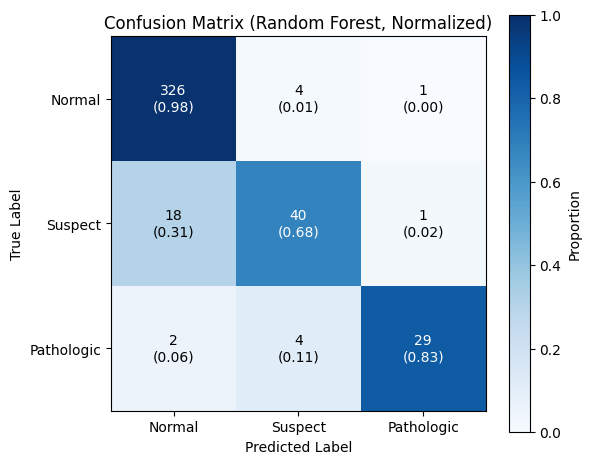

In [87]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Normal", "Suspect", "Pathologic"]

# compute confusion matrix for RF
cm = confusion_matrix(y_test, y_pred_rf)

# normalize by rows
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (Random Forest, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()


### Baseline model 3 -XGBoost

In [88]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)

y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

xgb.fit(X_train_scaled, y_train_xgb)
y_pred_xgb = xgb.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:15:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [89]:
from sklearn.metrics import classification_report, balanced_accuracy_score

y_pred_xgb_original = y_pred_xgb + 1

print("XGBoost")
print(classification_report(
    y_test,
    y_pred_xgb_original,
    target_names=["Normal", "Suspect", "Pathologic"]
))

bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb_original)
print("Balanced Accuracy:", bal_acc_xgb)

XGBoost
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97       331
     Suspect       0.87      0.76      0.81        59
  Pathologic       0.97      0.86      0.91        35

    accuracy                           0.94       425
   macro avg       0.93      0.87      0.90       425
weighted avg       0.94      0.94      0.94       425

Balanced Accuracy: 0.8682496604561226


* Overall accuracy of 94%, consistent with Random Forest but with better minority class performance
* Balanced accuracy improves to 0.87, up from 0.83 (Random Forest) and 0.74 (baseline)
* Normal class: recall of 0.98 — remains strong across all models
* Pathologic class: recall improves to 0.86, up from 0.83 in Random Forest
* Suspect class: recall improves to 0.76, up from 0.68 in Random Forest — a notable gain on the hardest class
* XGBoost consistently outperforms across all minority classes, making it the strongest candidate for further hyperparameter tuning

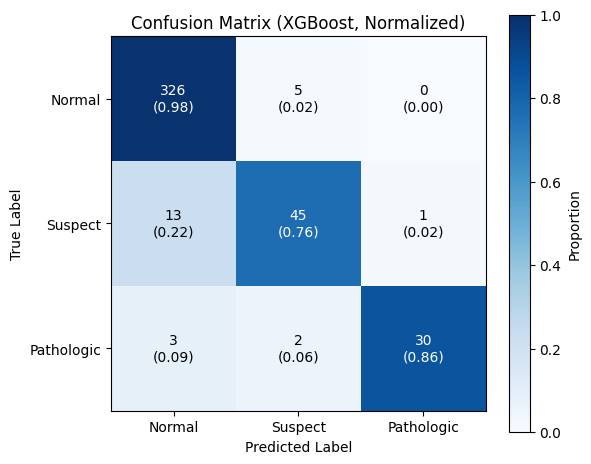

In [90]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Normal", "Suspect", "Pathologic"]

# Compute confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb_original)

# Normalize by rows
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (XGBoost, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

### Baseline model 4 -SVM

In [91]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [92]:
from sklearn.metrics import classification_report, balanced_accuracy_score

print("SVM")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Normal", "Suspect", "Pathologic"]
))

bal_acc_svm = balanced_accuracy_score(y_test, y_pred_svm)
print("Balanced Accuracy:", bal_acc_svm)

SVM
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       331
     Suspect       0.67      0.63      0.65        59
  Pathologic       0.92      0.66      0.77        35

    accuracy                           0.90       425
   macro avg       0.84      0.75      0.79       425
weighted avg       0.89      0.90      0.89       425

Balanced Accuracy: 0.751350006949372


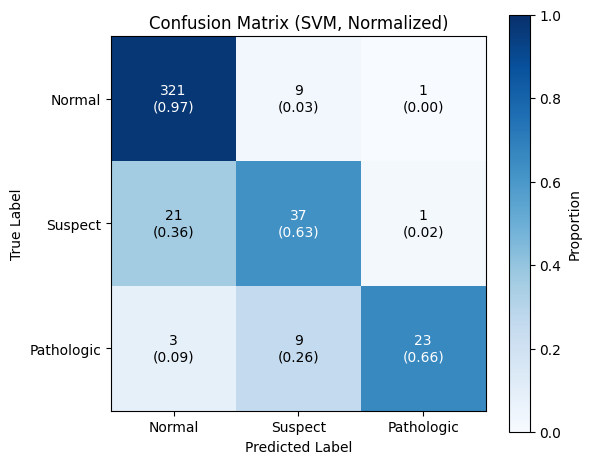

In [93]:
cm = confusion_matrix(y_test, y_pred_svm)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (SVM, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

In [102]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report

models = {
    "Logistic Regression": (y_pred_lr, y_test),
    "Random Forest":       (y_pred_rf, y_test),
    "XGBoost":             (y_pred_xgb_original, y_test),
    "SVM":                 (y_pred_svm, y_test),
}

print(f"{'Model':<25} {'Accuracy':>10} {'Bal. Acc':>10} {'Normal R':>10} {'Suspect R':>10} {'Pathologic R':>13}")
print("-" * 80)

best_bal_acc = ("", 0)
best_suspect = ("", 0)
best_patho   = ("", 0)
worst_bal    = ("", 1)

for name, (y_pred, y_true) in models.items():
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    report  = classification_report(y_true, y_pred, output_dict=True, target_names=["Normal", "Suspect", "Pathologic"])
    normal_r  = report["Normal"]["recall"]
    suspect_r = report["Suspect"]["recall"]
    patho_r   = report["Pathologic"]["recall"]
    print(f"{name:<25} {acc:>10.2f} {bal_acc:>10.2f} {normal_r:>10.2f} {suspect_r:>10.2f} {patho_r:>13.2f}")

    if bal_acc > best_bal_acc[1]: best_bal_acc = (name, bal_acc)
    if suspect_r > best_suspect[1]: best_suspect = (name, suspect_r)
    if patho_r > best_patho[1]: best_patho = (name, patho_r)
    if bal_acc < worst_bal[1]: worst_bal = (name, bal_acc)

print("-" * 80)
print(f"\nBest Balanced Accuracy : {best_bal_acc[0]} ({best_bal_acc[1]:.2f})")
print(f"Best Suspect Recall    : {best_suspect[0]} ({best_suspect[1]:.2f})")
print(f"Best Pathologic Recall : {best_patho[0]} ({best_patho[1]:.2f})")
print(f"Weakest Overall        : {worst_bal[0]} ({worst_bal[1]:.2f} balanced accuracy)")

Model                       Accuracy   Bal. Acc   Normal R  Suspect R  Pathologic R
--------------------------------------------------------------------------------
Logistic Regression             0.88       0.74       0.95       0.61          0.66
Random Forest                   0.93       0.83       0.98       0.68          0.83
XGBoost                         0.94       0.87       0.98       0.76          0.86
SVM                             0.90       0.75       0.97       0.63          0.66
--------------------------------------------------------------------------------

Best Balanced Accuracy : XGBoost (0.87)
Best Suspect Recall    : XGBoost (0.76)
Best Pathologic Recall : XGBoost (0.86)
Weakest Overall        : Logistic Regression (0.74 balanced accuracy)


# Step 4️ K-Fold Cross-Validation (Model Selection)

In [95]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score
import numpy as np

# Define 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        use_label_encoder=False
    ),
    'SVM': SVC(kernel='rbf', random_state=42)
}


In [96]:
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}...")
    print(f"{'='*50}")

    # Prepare labels for XGBoost (0-indexed)
    if name == 'XGBoost':
        y_cv = y_train - 1
    else:
        y_cv = y_train

    ba_scores = cross_val_score(
        model, X_train_scaled, y_cv,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )


    f1_scores = cross_val_score(
        model, X_train_scaled, y_cv,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_results[name] = {
        'balanced_accuracy': ba_scores,
        'f1_macro': f1_scores,
        'ba_mean': ba_scores.mean(),
        'ba_std': ba_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std()
    }

    print(f"Balanced Accuracy: {ba_scores.mean():.4f} (+/- {ba_scores.std():.4f})")
    print(f"Macro F1-Score:    {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")


Evaluating LogisticRegression...
Balanced Accuracy: 0.7897 (+/- 0.0210)
Macro F1-Score:    0.8004 (+/- 0.0262)

Evaluating RandomForest...
Balanced Accuracy: 0.8799 (+/- 0.0244)
Macro F1-Score:    0.8983 (+/- 0.0198)

Evaluating XGBoost...
Balanced Accuracy: 0.9018 (+/- 0.0250)
Macro F1-Score:    0.9176 (+/- 0.0202)

Evaluating SVM...
Balanced Accuracy: 0.7965 (+/- 0.0284)
Macro F1-Score:    0.8313 (+/- 0.0256)


Cross-Validation Results & Model Selection



* XGBoost leads with the highest CV balanced accuracy (0.90) and macro F1-score (0.92), confirming its superiority across folds
* Random Forest follows closely with CV balanced accuracy of 0.88 and macro F1 of 0.90 — a solid alternative
* Logistic Regression (0.79) and SVM (0.80) lag behind, not worth tuning further given the performance gap
* All models show consistency between CV and test results with low variance, indicating no overfitting
* Rankings remain stable across both CV and held-out test evaluation, adding confidence to model selection
* XGBoost selected for hyperparameter tuning — highest balanced accuracy, best macro F1, and most robust handling of minority classes



---



# Step 5️ Hyperparameter Tuning (Grid Search)

An XGBoost classifier was trained using GridSearchCV with 5-fold Stratified K-Fold cross-validation across key hyperparameters including number of estimators, tree depth, learning rate, subsample ratio, and minimum child weight.

Given the clinical significance of detecting pathologic cases, a custom refit strategy was applied to select the best model based on a composite score combining balanced accuracy and Pathologic class recall equally.

The final model was evaluated on a held-out test set using classification report, balanced accuracy, and Pathologic recall.

In [103]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    recall_score,
    make_scorer
)
from xgboost import XGBClassifier

# Step 1: Prepare labels (0-indexed for XGBoost)
y_train_xgb = y_train - 1
y_test_xgb  = y_test - 1

# Step 2: Custom Pathologic recall scorer (class index 2)
pathologic_recall = make_scorer(
    recall_score,
    labels=[2],
    average='macro'
)

# Step 3: Multi-metric scoring
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro':          'f1_macro',
    'pathologic_recall': pathologic_recall
}

# Step 4: Custom refit — balances both balanced_accuracy + pathologic_recall
def custom_refit(cv_results):
    ba = np.array(cv_results['mean_test_balanced_accuracy'])
    pr = np.array(cv_results['mean_test_pathologic_recall'])
    combined = 0.5 * ba + 0.5 * pr
    return np.argmax(combined)

# Step 5: Base XGBoost model
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

# Step 6: Parameter grid
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

# Step 7: StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 8: GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=scoring,
    refit=custom_refit,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_xgb)

# Step 9: Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Step 10: Evaluate on test set
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)
y_pred_tuned_orig = y_pred_tuned + 1

print("\n--- Tuned XGBoost Results ---")
print(classification_report(
    y_test,
    y_pred_tuned_orig,
    target_names=['Normal', 'Suspect', 'Pathologic']
))

bal_acc_tuned = balanced_accuracy_score(y_test, y_pred_tuned_orig)
print(f"Balanced Accuracy (Tuned):   {bal_acc_tuned:.4f}")

patho_recall_tuned = recall_score(y_test, y_pred_tuned_orig, labels=[3], average='macro')
print(f"Pathologic Recall (Tuned):   {patho_recall_tuned:.4f}")

f1_tuned = f1_score(y_test, y_pred_tuned_orig, average='macro')
print(f"Macro F1-Score (Tuned):      {f1_tuned:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}

--- Tuned XGBoost Results ---
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       331
     Suspect       0.92      0.75      0.82        59
  Pathologic       0.94      0.89      0.91        35

    accuracy                           0.95       425
   macro avg       0.94      0.87      0.90       425
weighted avg       0.94      0.95      0.94       425

Balanced Accuracy (Tuned):   0.8731
Pathologic Recall (Tuned):   0.8857
Macro F1-Score (Tuned):      0.9010


Hyperparameter tuning via GridSearchCV further optimised the model, achieving a final balanced accuracy of 0.87, pathologic recall of 0.89, and macro F1 of 0.90 on the test set. The model performs particularly well in identifying Pathologic cases, which is critical in a clinical context where missed detections carry the highest risk.

The main limitation is suspect recall at 0.75, reflecting the natural scarcity of suspect cases in the dataset. Future work could explore oversampling techniques such as SMOTE or collecting more suspect-class data to address this gap.

# Feature Importance Analysis


Top 10 Most Important Features:
   Feature  Importance
17    Mean    0.141596
5     MSTV    0.126056
1       AC    0.120376
10      DP    0.117087
4     ASTV    0.102968
6     ALTV    0.088465
16    Mode    0.038825
3       UC    0.038262
18  Median    0.036739
14     Max    0.027655


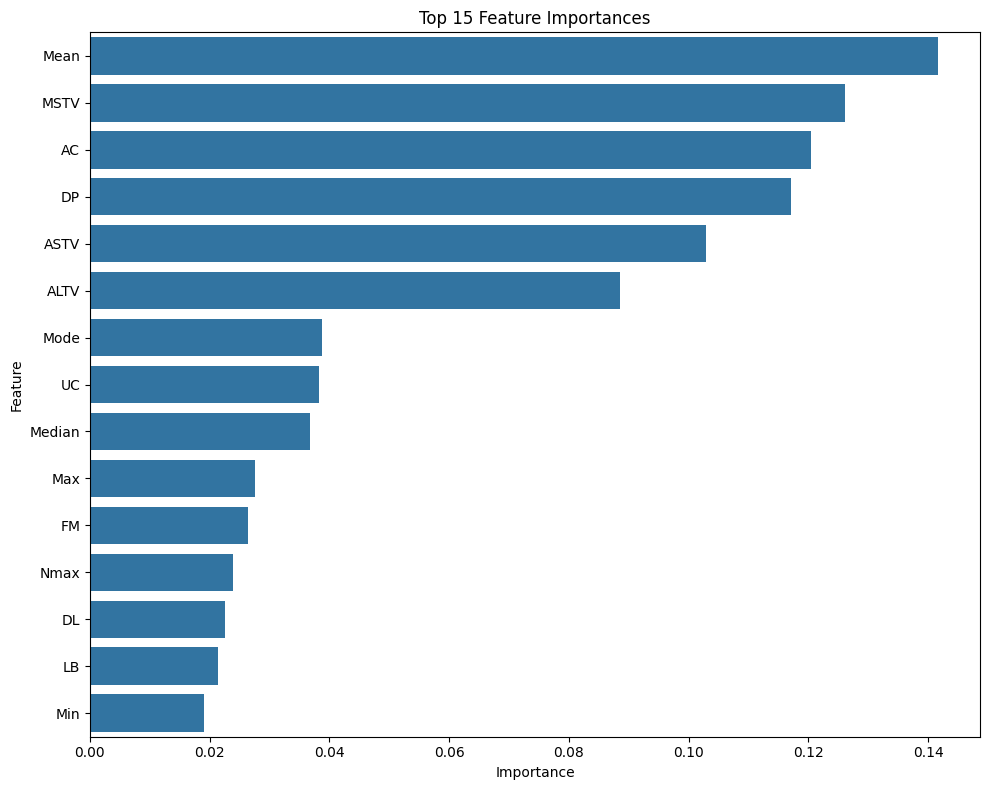

In [98]:
feature_importance = best_xgb.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

* Mean (0.14) emerges as the most important feature — the histogram mean of fetal heart rate is a strong indicator of fetal state
* MSTV (0.13) and ASTV (0.10) — short term variability features rank highly, reflecting how reduced variability is a key warning sign in CTG interpretation
* AC (0.12) — accelerations are a well-established positive indicator of fetal wellbeing, so its high importance is clinically expected
* DP (0.12) — prolonged decelerations are a critical danger signal, consistent with its high ranking
* ALTV (0.09) — abnormal long term variability further supports the model's reliance on variability-based signals
* Lower-ranked features (Mode, UC, Median, Max) contribute moderately but are not primary drivers


SHAP Summary — Normal


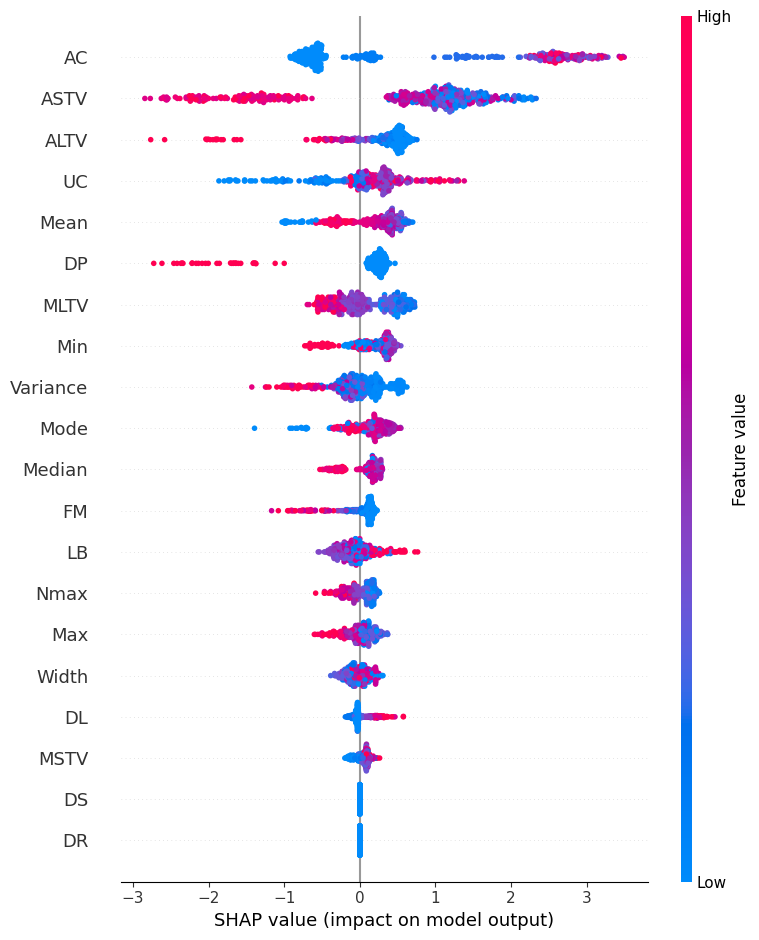


SHAP Summary — Suspect


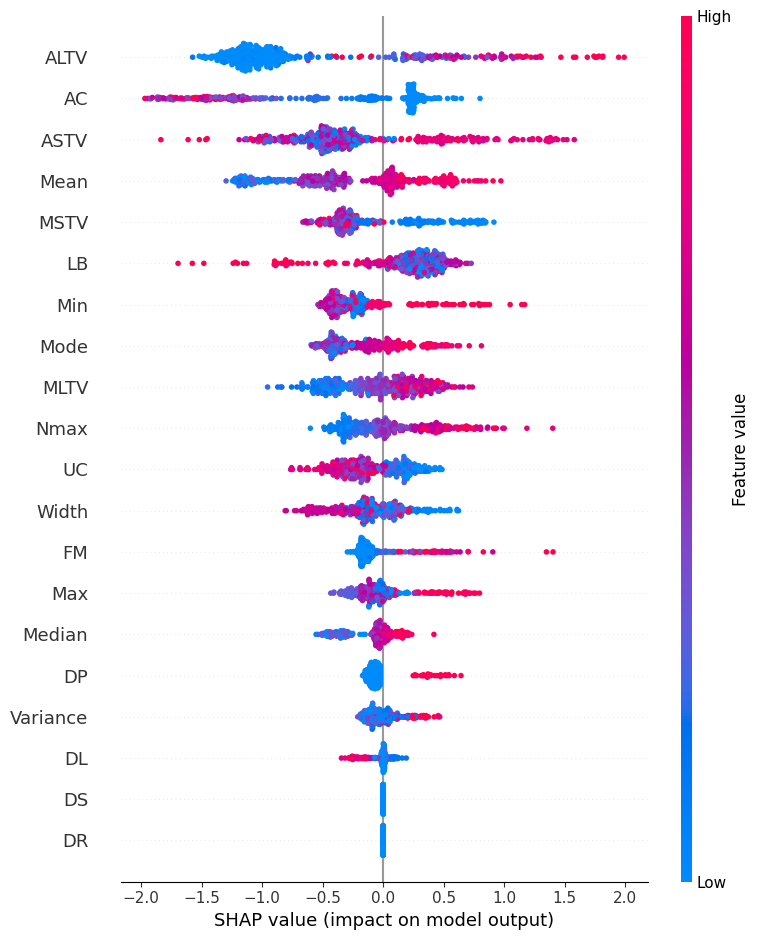


SHAP Summary — Pathologic


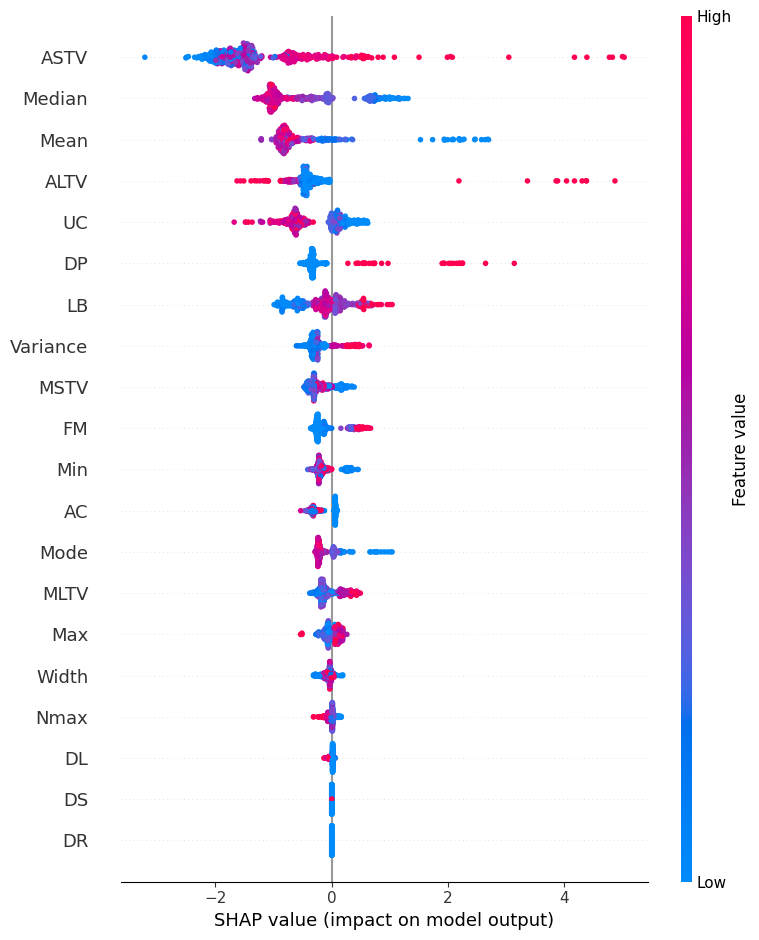

In [108]:
import shap

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_df)  # pass DataFrame here instead

for i, cls in enumerate(['Normal', 'Suspect', 'Pathologic']):
    print(f"\nSHAP Summary — {cls}")
    shap.summary_plot(shap_values[:, :, i], X_test_df)

➜ Positive SHAP value (right side) = pushes prediction toward Pathological (Class 3)

➜ Negative SHAP value (left side) = pushes prediction away from pathological (more toward healthy/concern)



---



SHAP Analysis — Pathologic Class

* ASTV is the dominant feature — high ASTV values strongly push predictions towards the Pathologic class, indicating abnormal short-term variability is a major indicator of fetal distress.
* ALTV shows a similar pattern, where high values positively contribute to Pathologic classification, reinforcing the importance of variability abnormalities.
* DP (Prolonged Decelerations) — high values increase the likelihood of Pathologic prediction, consistent with clinical understanding of prolonged decelerations as a danger sign.
* UC (Uterine Contractions) — lower UC values are associated with increased Pathologic prediction, while higher values tend to reduce Pathologic classification.
* Mean and Median — lower values contribute positively towards Pathologic prediction, suggesting lower baseline fetal heart rate is associated with pathological conditions.
* AC (Accelerations) — low acceleration values are associated with Pathologic outcomes, aligning with clinical knowledge that reduced accelerations may indicate fetal compromise.
* DS and DR contribute minimally to overall model predictions, indicating limited influence on classification performance.

# Save the tuned XGBoost model

In [109]:
import joblib

joblib.dump(best_xgb, "xgb_ctg_tuned_model.joblib")


['xgb_ctg_tuned_model.joblib']

In [110]:
joblib.dump(scaler, "ctg_scaler.joblib")

['ctg_scaler.joblib']

In [111]:
joblib.dump(X_train.columns.tolist(), "ctg_features.joblib")

['ctg_features.joblib']